In [7]:
import pandas as pd

df = pd.read_csv("messy_sales.csv")

In [9]:
df.head()

,Order_ID,Date,Product,Category,Quantity,Price,City
0,1001,2024-01-05,Laptop,Electronics,2,1200.0,Baku
1,1002,2024-01-06,Mouse,Electronics,5,25.0,Ganja
2,1003,2024-01-06,Keyboard,Electronics,3,45.0,Sumgait
3,1004,2024-01-08,Chair,Furniture,2,150$,Baku
4,1005,2024-01-10,Desk,Furniture,1,300.0,Ganja


Looking for numbers of not-null values in each columns and for their types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  32 non-null     int64 
 1   Date      32 non-null     object
 2   Product   32 non-null     object
 3   Category  32 non-null     object
 4   Quantity  32 non-null     int64 
 5   Price     28 non-null     object
 6   City      25 non-null     object
dtypes: int64(2), object(5)
memory usage: 1.9+ KB


In [12]:
df.describe()

,Order_ID,Quantity
count,32.000000,32.000000
mean,1632.937500,4.343750
std,493.943443,4.974836
min,1001.000000,1.000000
25%,1006.750000,1.750000
50%,2003.500000,2.000000
75%,2011.250000,4.250000
max,2019.000000,20.000000


numbers of null values in columns

In [13]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product,0
Category,0
Quantity,0
Price,4
City,7


In [15]:
df.duplicated().sum()

np.int64(2)

Remove duplicate rows

In [16]:
df=df.drop_duplicates()

In [17]:
df["City"]=df['City'].fillna("Unknown")

Change type of "Price" column to str and use str command "replace()", then change to numeric and fill null cells with mean of column

In [18]:
df["Price"] = df["Price"].astype(str)

df["Price"] = df["Price"].str.replace("$","", regex=False)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Price"] = df["Price"].fillna(df["Price"].mean())

In [19]:
df["Quantity"] = df["Quantity"].astype(str).str.strip()

df["Quantity"] = pd.to_numeric(df["Quantity"])

In [20]:
df.tail(5)

,Order_ID,Date,Product,Category,Quantity,Price,City
25,2015,2024-01-06,keyboard,Electronics,3,201.884615,Unknown
26,2016,2024-01-13,PEN,stationery,20,2.000000,Sumgait
27,2017,2024-01-15,monitor,Electronics,2,350.000000,Baku
28,2018,2024-01-15,MONITOR,Electronics,2,350.000000,Unknown
29,2019,2024-01-06,mouse,Electronics,5,25.000000,Ganja


Convert Product names to Title Case

In [21]:
df['Product']=df['Product'].str.lower().str.title()

In [22]:
df['Category']=df['Category'].str.lower().str.title()

Remove spaces from all text columns

In [23]:
text_columns = ["Product","Category","City"]

for col in text_columns:
    df[col] = df[col].str.strip()

Convert Date to datetime

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

Create Total Sales column

In [28]:
df["Total"]=df["Price"]*df["Quantity"]

In [29]:
df.to_csv("clean_sales.csv", index=False)

# Matplotlib Charts

Total Sales by Product

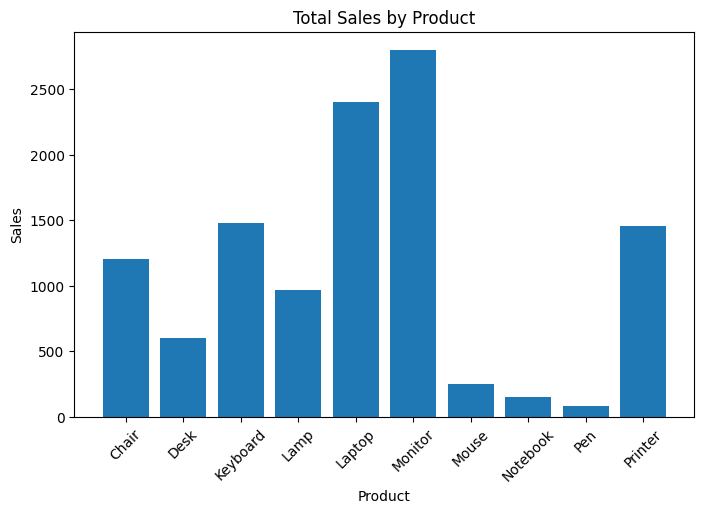

In [30]:
import matplotlib.pyplot as plt

sales = df.groupby("Product")["Total"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales.index, sales.values)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

Quantity Sold by City

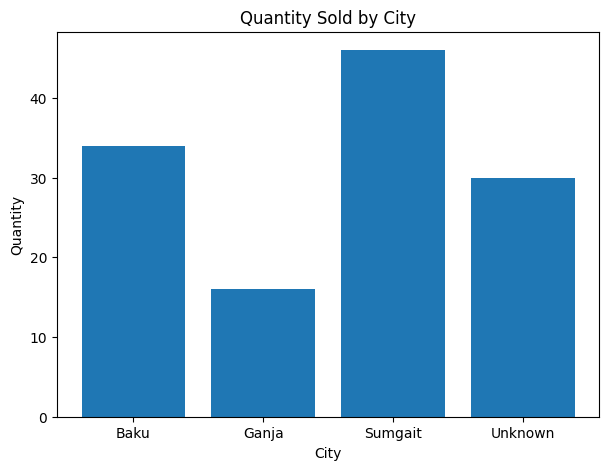

In [31]:
city = df.groupby("City")["Quantity"].sum()

plt.figure(figsize=(7,5))

plt.bar(city.index, city.values)

plt.title("Quantity Sold by City")
plt.xlabel("City")
plt.ylabel("Quantity")

plt.show()

Average Price of Products

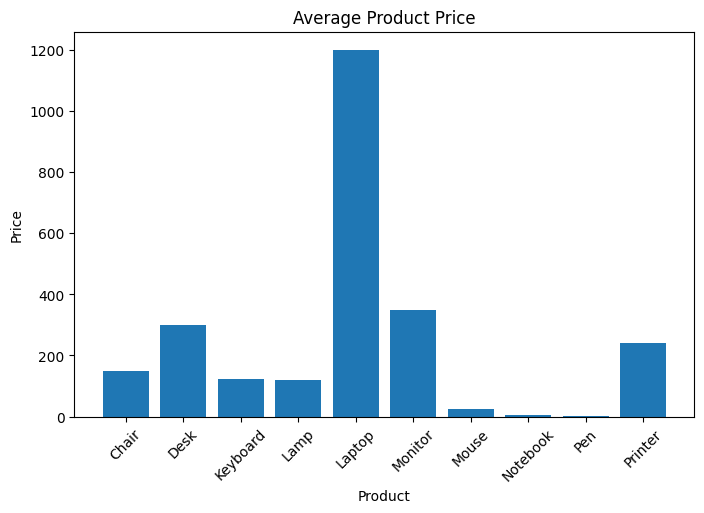

In [32]:
price = df.groupby("Product")["Price"].mean()

plt.figure(figsize=(8,5))

plt.bar(price.index, price.values)

plt.title("Average Product Price")
plt.xlabel("Product")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

Orders per Category

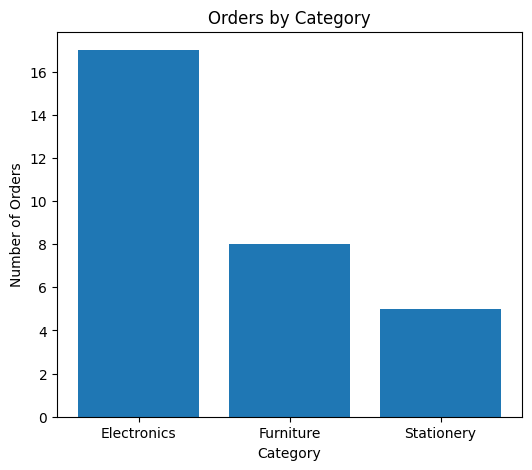

In [33]:
category = df["Category"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(category.index, category.values)

plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

Daily Sales

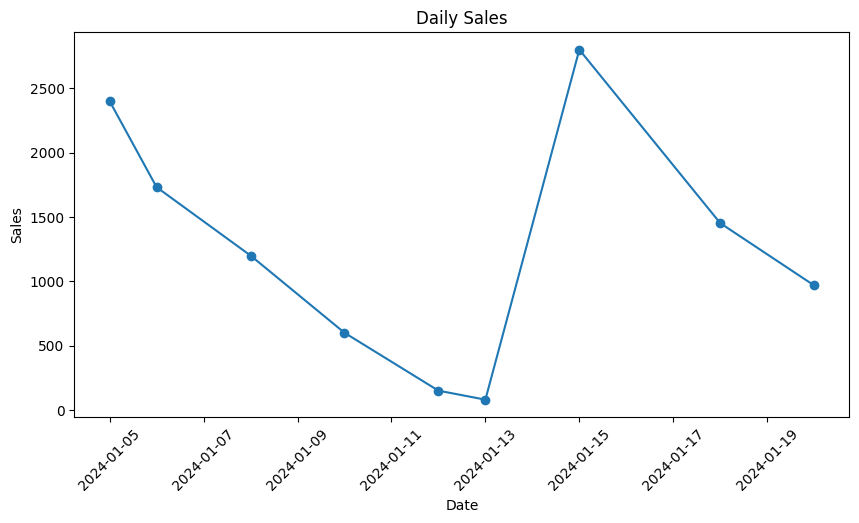

In [34]:
daily = df.groupby("Date")["Total"].sum()

plt.figure(figsize=(10,5))

plt.plot(daily.index, daily.values, marker="o")

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

Top 5 Products by Sales

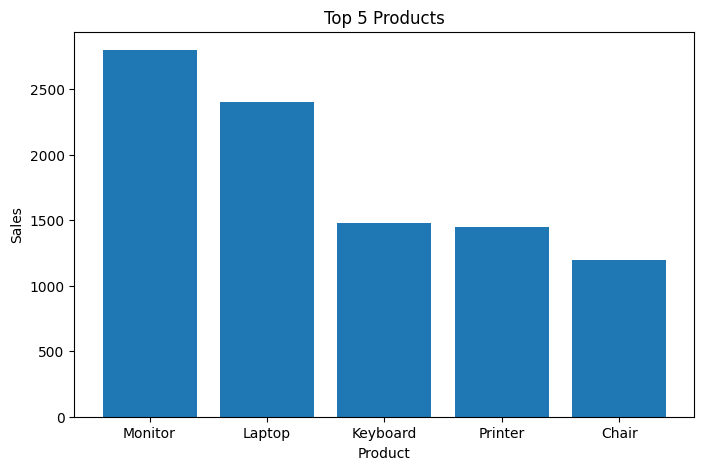

In [35]:
top = df.groupby("Product")["Total"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))

plt.bar(top.index, top.values)

plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()